In [6]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 125 (delta 50), reused 55 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 4.06 MiB | 6.63 MiB/s, done.
Resolving deltas: 100% (50/50), done.


In [7]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet
from src.bbbc038_dataset import BBBC038Dataset, InstanceEvaluationSubset

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [9]:
dataset = BBBC038Dataset(root_dir='./data', img_size=128, download=True)

train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15])

print(f"Total: {len(dataset)} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Extracting data/stage1_train.zip ...
Total: 670 | Train: 469 | Val: 101 | Test: 100


In [10]:
# Treinando a ResUNet no BBBC038

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.7264673709869385
0/5 - loss=0.6341685652732849
0/10 - loss=0.5804759860038757
0/15 - loss=0.5537651777267456
0/20 - loss=0.5196545124053955
0/25 - loss=0.454420268535614
1/0 - loss=0.4186898469924927
1/5 - loss=0.3448306918144226
1/10 - loss=0.34405601024627686
1/15 - loss=0.2959696054458618
1/20 - loss=0.3031342327594757
1/25 - loss=0.3026449978351593
2/0 - loss=0.26911649107933044
2/5 - loss=0.20916780829429626
2/10 - loss=0.22790789604187012
2/15 - loss=0.22683490812778473
2/20 - loss=0.19091154634952545
2/25 - loss=0.2090374380350113
3/0 - loss=0.25147008895874023
3/5 - loss=0.21208590269088745
3/10 - loss=0.18397322297096252
3/15 - loss=0.1760236918926239
3/20 - loss=0.22795113921165466
3/25 - loss=0.16246306896209717
4/0 - loss=0.17481163144111633
4/5 - loss=0.24155166745185852
4/10 - loss=0.15020450949668884
4/15 - loss=0.1727406084537506
4/20 - loss=0.1626107543706894
4/25 - loss=0.14061781764030457


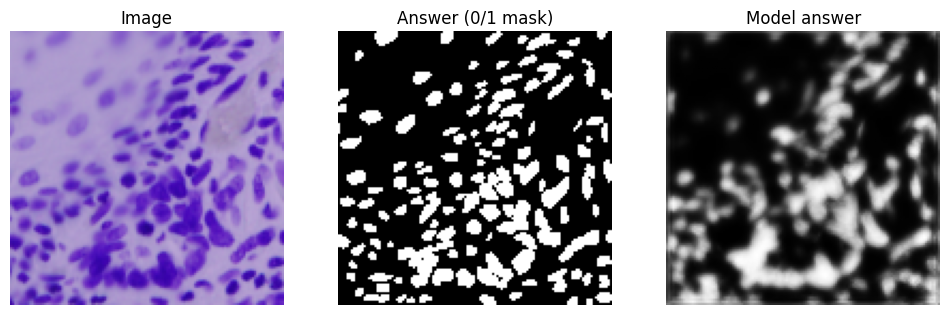

In [11]:
# Verificando a saída do modelo

model.eval()

for img, mask in DataLoader(test_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")


    plt.show()

    break

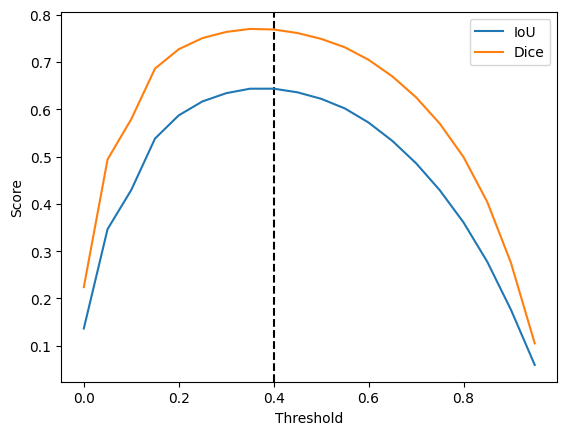

IoU final: 0.638580322265625
Dice final: 0.7666382789611816


In [12]:
# computa o IoU e Dice no conjunto de validação/teste

model.eval()

def pred(x):
    return torch.sigmoid(model(x.to(device)))[0].cpu()

thresholds = torch.arange(0, 1, .05)

with torch.no_grad():
    # encontra o melhor limiar com o conjunto de validação
    iou_scores, dice_scores = [], []
    for x, y in DataLoader(val_dataset, pin_memory=True):
        y_hat = pred(x)
        iou_scores.append([float(utils.iou_score(1 * (y_hat > th), y)) for th in thresholds])
        dice_scores.append([float(utils.dice_score(1 * (y_hat > th), y)) for th in thresholds])

    iou_scores = torch.tensor(iou_scores).mean(dim=0)
    dice_scores = torch.tensor(dice_scores).mean(dim=0)
    best_threshold = thresholds[iou_scores.argmax()]

    plt.axvline(best_threshold, color='k', linestyle='--')
    plt.plot(thresholds, iou_scores, label='IoU')
    plt.plot(thresholds, dice_scores, label='Dice')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

    # computa o IoU e Dice pontuais no conjunto de teste
    iou_scores_test, dice_scores_test = [], []
    for x, y in DataLoader(test_dataset, pin_memory=True):
        y_hat = pred(x)
        iou_scores_test.append(float(utils.iou_score(1 * (y_hat > best_threshold), y)))
        dice_scores_test.append(float(utils.dice_score(1 * (y_hat > best_threshold), y)))

    final_iou_score = torch.tensor(iou_scores_test).mean().item()
    final_dice_score = torch.tensor(dice_scores_test).mean().item()

    print("IoU final:", final_iou_score)
    print("Dice final:", final_dice_score)

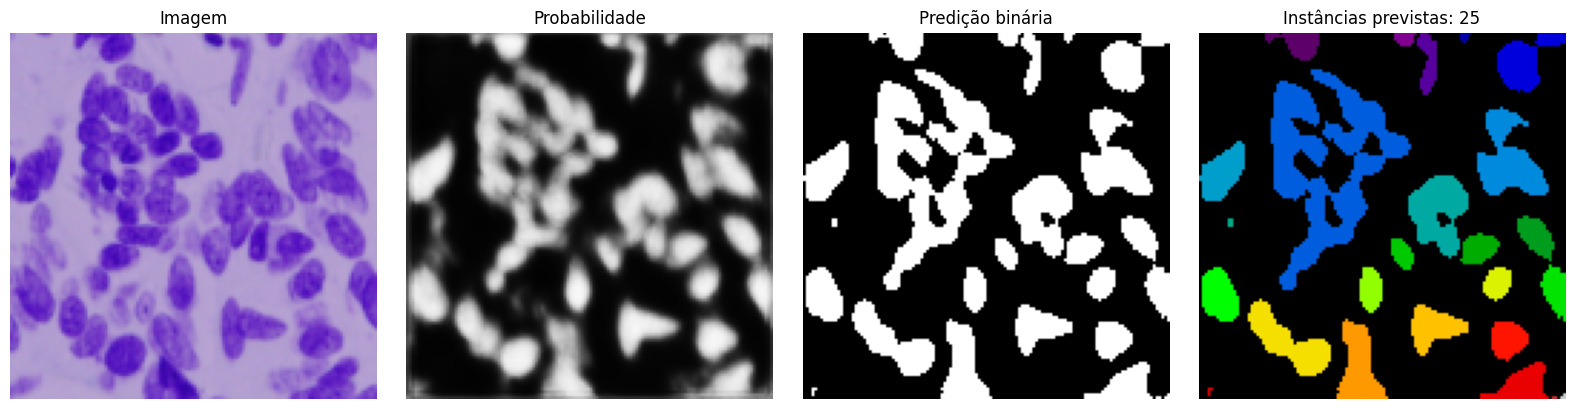

In [13]:
model.eval()

with torch.no_grad():
    for img, mask in DataLoader(test_dataset, shuffle=True):
        img_device = img.to(device)

        probability = torch.sigmoid(
            model(img_device)
        )[0, 0].cpu().numpy()

        pred_instance_map = utils.probability_to_instances(
            probability,
            threshold=0.5
        )

        binary_prediction = probability >= 0.5
        n_pred = pred_instance_map.max()

        image = img[0].permute(1, 2, 0).numpy()
        ground_truth = mask[0].numpy()

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        axes[0].imshow(image)
        axes[0].set_title("Imagem")

        axes[1].imshow(probability, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Probabilidade")

        axes[2].imshow(binary_prediction, cmap="gray")
        axes[2].set_title("Predição binária")

        axes[3].imshow(pred_instance_map, cmap="nipy_spectral")
        axes[3].set_title(f"Instâncias previstas: {n_pred}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        break

In [14]:
instance_test_dataset = InstanceEvaluationSubset(
    original_dataset=dataset,
    indices=test_dataset.indices
)

instance_test_loader = DataLoader(
    instance_test_dataset,
    batch_size=1,
    shuffle=False
)

ID: 33618678c167c5e07be02c49d0c43bcd90493ba5d83110a631409a4d3ccc1e51
Número de instancias GT: 19


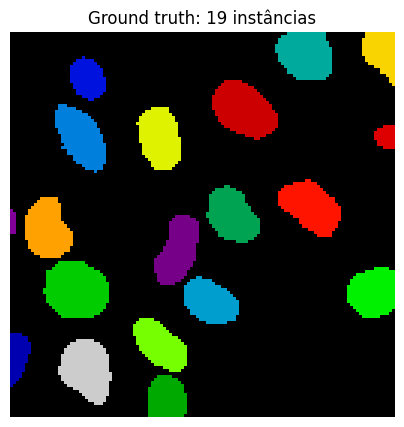

In [15]:
image, semantic_mask, instance_map, image_id = next(
    iter(instance_test_loader)
)

print("ID:", image_id[0])
print("Número de instancias GT:", instance_map.max().item())

plt.figure(figsize=(5, 5))
plt.imshow(instance_map[0], cmap="nipy_spectral")
plt.title(f"Ground truth: {instance_map.max().item()} instâncias")
plt.axis("off")
plt.show()

In [16]:
gt_map = instance_map[0].cpu().numpy()

model.eval()

with torch.no_grad():
    logits = model(image.to(device))

    probability = torch.sigmoid(
        logits
    )[0, 0].cpu().numpy()

pred_map = utils.probability_to_instances(
    probability,
    threshold=0.5
)

print("ID:", image_id[0])
print("Número de instâncias GT:", gt_map.max())
print("Número de instâncias previstas:", pred_map.max())

ID: 33618678c167c5e07be02c49d0c43bcd90493ba5d83110a631409a4d3ccc1e51
Número de instâncias GT: 19
Número de instâncias previstas: 14


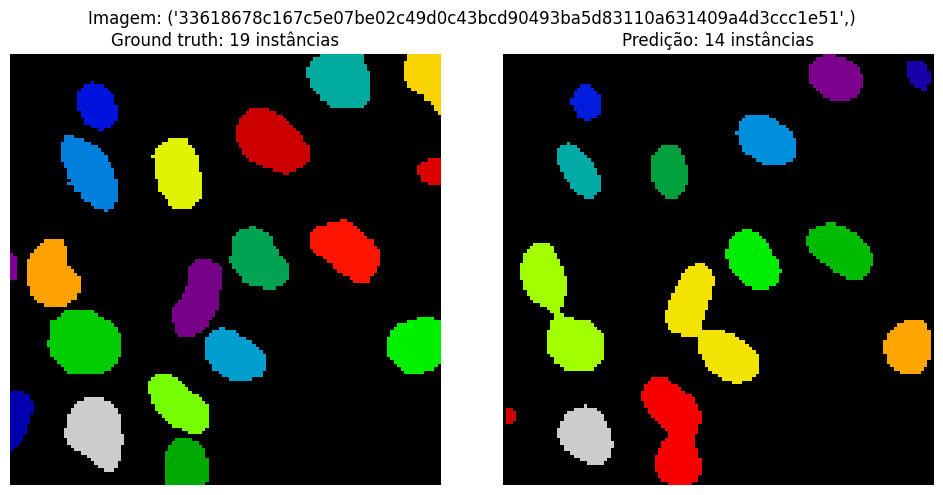

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    gt_map,
    cmap="nipy_spectral",
    interpolation="nearest"
)
axes[0].set_title(
    f"Ground truth: {gt_map.max()} instâncias"
)

axes[1].imshow(
    pred_map,
    cmap="nipy_spectral",
    interpolation="nearest"
)
axes[1].set_title(
    f"Predição: {pred_map.max()} instâncias"
)

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Imagem: {image_id}")
plt.tight_layout()
plt.show()